# Unit09_ODE | 常微分方程式 (ODE) 之求解

本 Notebook 示範使用 `scipy.integrate` 模組求解化工程序中的常微分方程式問題，涵蓋起始值問題 (IVP)、Stiff ODE、微分代數系統 (DAE) 與邊界值問題 (BVP)。

## 目標
- 使用 `scipy.integrate.solve_ivp()` 求解聯立一階 IVP ODE
- 比較 Non-stiff (RK45) 與 Stiff (Radau/BDF) 求解器的差異
- 示範微分代數系統 (DAE) 的處理策略
- 使用 `scipy.integrate.solve_bvp()` 求解兩點邊界值問題 (BVP)

## 內容大綱
- [0. 環境設定](#0)
- [1. 載入套件](#1)
- [2. 常微分方程式系統基礎](#2)
  - [2.1 IVP 問題形式](#2-1)
  - [2.2 高階 ODE 轉換示範](#2-2)
- [3. SciPy IVP 求解工具 solve_ivp()](#3)
  - [3.1 基本語法與求解方法](#3-1)
  - [3.2 精度控制與外部輸入函數](#3-2)
  - [3.3 CSTR 動態模擬範例](#3-3)
- [4. Stiff 常微分方程式](#4)
  - [4.1 識別 Stiff 問題：特徵值分析](#4-1)
  - [4.2 Non-stiff 與 Stiff 求解器比較](#4-2)
- [5. 微分代數系統 (DAE)](#5)
  - [5.1 DAE 問題示範：三成分反應系統](#5-1)
- [6. 邊界值問題 (BVP)](#6)
  - [6.1 solve_bvp() 基本語法](#6-1)
  - [6.2 BVP 化工範例：PFR 軸向濃度與溫度分佈](#6-2)
  - [6.3 含未知參數的 BVP（特徵值問題）](#6-3)
- [7. 課程總結](#7)


---
<a id="0"></a>
### 0. 環境設定

In [19]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit09_ODE'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit09'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit09
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_ODE
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_ODE\figs


---
<a id="1"></a>
### 1. 載入套件

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# SciPy ODE 求解模組
from scipy.integrate import solve_ivp, solve_bvp

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
import scipy
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


<a id="2"></a>
## 2. 常微分方程式系統基礎

本章介紹 IVP（初值問題）的數學形式，以化工常見的 CSTR（連續攪拌槽反應器）為例，示範如何將物理問題轉換為 ODE 系統，並說明高階 ODE 的狀態空間轉換方法。

### 2.1 IVP 問題形式

**一階 ODE 系統（標準形式）：**

$$
\frac{d\mathbf{y}}{dt} = \mathbf{f}(t,\, \mathbf{y}), \quad \mathbf{y}(t_0) = \mathbf{y}_0
$$

其中 $\mathbf{y} \in \mathbb{R}^n$ 為狀態向量， $\mathbf{f}$ 為右端函數向量。

**化工範例：CSTR 能量平衡**

考慮含放熱反應的 CSTR，其無因次化方程式為：

$$
\frac{dx}{dt} = -Da \cdot x \cdot e^{-\phi/(1+T)} + Da(1-x)
$$

$$
\frac{dT}{dt} = Da \cdot B \cdot x \cdot e^{-\phi/(1+T)} - Da \cdot T - \beta(T - T_c)
$$

其中 $x$ 為無因次濃度（入口 $x_f=1$）， $T$ 為無因次溫度差，參數 $Da=0.5$，$\phi=6$，$B=50$，$\beta=0.5$，$T_c=0$。

此參數組合存在三個穩態，能量守恆溫度 $T_{max}=B \cdot Da/(Da+\beta)=25$，為多穩態 CSTR 的典型示範。

求解狀態: The solver successfully reached the end of the integration interval.
ODE 函數呼叫次數: 418
最終狀態: x=0.6487, T=8.7824
能量守恆驗證 T_ss = B*Da*(1-x)/(Da+β) = 8.7824


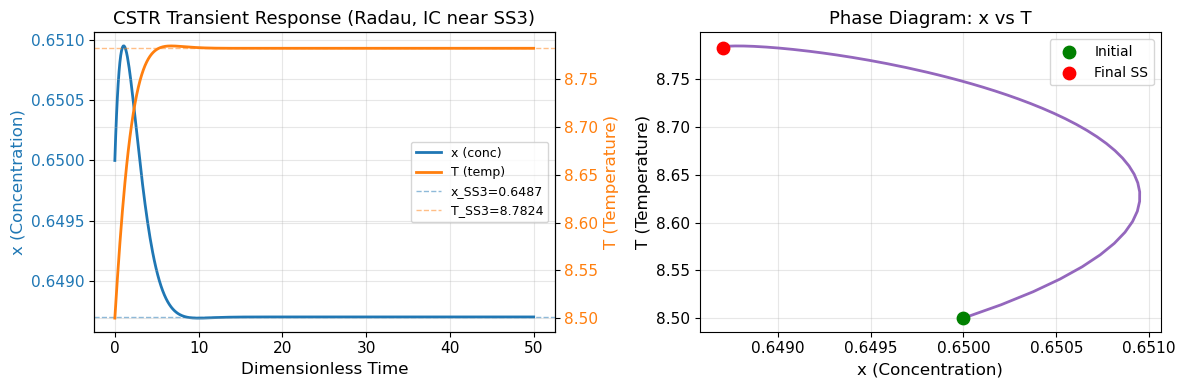

圖檔已儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_ODE\figs\cstr_basic_ivp.png


In [33]:
# ─────────────────────────────────────────────────
# Example 2.1 - CSTR 基本 IVP 求解
# ─────────────────────────────────────────────────

def cstr_ode(t, y, Da=0.5, phi=6.0, B=50.0, beta=0.5, yc=0.0):
    """
    CSTR ODE 右端函數（三穩態示範參數）
    y[0] = x (無因次濃度，入口 xf=1)
    y[1] = T (無因次溫度差)
    質量守恆: dxdt = -Da*x*exp(-phi/(1+T)) + Da*(1-x)
    能量守恆: dTdt =  B*Da*x*exp(-phi/(1+T)) - (Da+beta)*T
    參數：phi=6, B=50, Da=0.5, beta=0.5 → 存在三個穩態
    """
    x, T = y
    exp_term = np.exp(-phi / (1.0 + T))
    reaction = Da * x * exp_term          # = Da * x * exp(-phi/(1+T))
    dxdt = -reaction + Da * (1.0 - x)
    dTdt = B * reaction - Da * T - beta * (T - yc)   # 熱產生 = B*reaction
    return [dxdt, dTdt]

# 初始條件：接近高溫穩態 SS3 附近，觀察動態響應
y0 = [0.65, 8.5]         # 初始接近 SS3 (x≈0.65, T≈8.75)
t_span = (0.0, 50.0)
t_eval = np.linspace(0, 50, 500)

sol = solve_ivp(cstr_ode, t_span, y0, method='Radau', t_eval=t_eval,
                rtol=1e-8, atol=1e-10)

print(f"求解狀態: {sol.message}")
print(f"ODE 函數呼叫次數: {sol.nfev}")
print(f"最終狀態: x={sol.y[0,-1]:.4f}, T={sol.y[1,-1]:.4f}")
T_check = 50*0.5*(1-sol.y[0,-1])/1.0
print(f"能量守恆驗證 T_ss = B*Da*(1-x)/(Da+β) = {T_check:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左圖：左右雙 Y 軸，避免 x 與 T 尺度差異造成視覺混淆
ax_left = axes[0]
ax_right = ax_left.twinx()

l1, = ax_left.plot(sol.t, sol.y[0], label='x (conc)', color='tab:blue', linewidth=2)
l2, = ax_right.plot(sol.t, sol.y[1], label='T (temp)', color='tab:orange', linewidth=2)

ax_left.set_xlabel('Dimensionless Time')
ax_left.set_ylabel('x (Concentration)', color='tab:blue')
ax_right.set_ylabel('T (Temperature)', color='tab:orange')
ax_left.tick_params(axis='y', labelcolor='tab:blue')
ax_right.tick_params(axis='y', labelcolor='tab:orange')
ax_left.set_title('CSTR Transient Response (Radau, IC near SS3)')
# 穩態參考線
l3 = ax_left.axhline(y=0.6487, color='tab:blue', linestyle='--', linewidth=1.0, alpha=0.5)
l4 = ax_right.axhline(y=8.7824, color='tab:orange', linestyle='--', linewidth=1.0, alpha=0.5)
ax_left.legend(handles=[l1, l2, l3, l4],
               labels=['x (conc)', 'T (temp)', 'x_SS3=0.6487', 'T_SS3=8.7824'],
               loc='center right', fontsize=9)
ax_left.grid(True, alpha=0.3)

axes[1].plot(sol.y[0], sol.y[1], color='tab:purple')
axes[1].scatter(y0[0], y0[1], s=80, color='green', zorder=5, label='Initial')
axes[1].scatter(sol.y[0,-1], sol.y[1,-1], s=80, color='red', zorder=5, label='Final SS')
axes[1].set_xlabel('x (Concentration)')
axes[1].set_ylabel('T (Temperature)')
axes[1].set_title('Phase Diagram: x vs T')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / 'cstr_basic_ivp.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"圖檔已儲存：{FIG_DIR / 'cstr_basic_ivp.png'}")

### 2.2 高階 ODE 轉換為一階系統

`solve_ivp()` 只接受一階 ODE 系統。對於 $n$ 階 ODE，必須引入狀態變數進行轉換。

**範例：彈簧-質量-阻尼系統（二階ODE）**

$$
m\ddot{x} + c\dot{x} + kx = F(t)
$$

**轉換步驟：** 定義 $y_1 = x$，$y_2 = \dot{x}$，則：

$$
\begin{aligned}
\dot{y}_1 &= y_2 \\
\dot{y}_2 &= \frac{1}{m}\left[F(t) - c\,y_2 - k\,y_1\right]
\end{aligned}
$$

**一般法則：** $n$ 階 ODE → $n$ 個狀態變數 → 一階系統（維度 $n$）

求解狀態: The solver successfully reached the end of the integration interval.


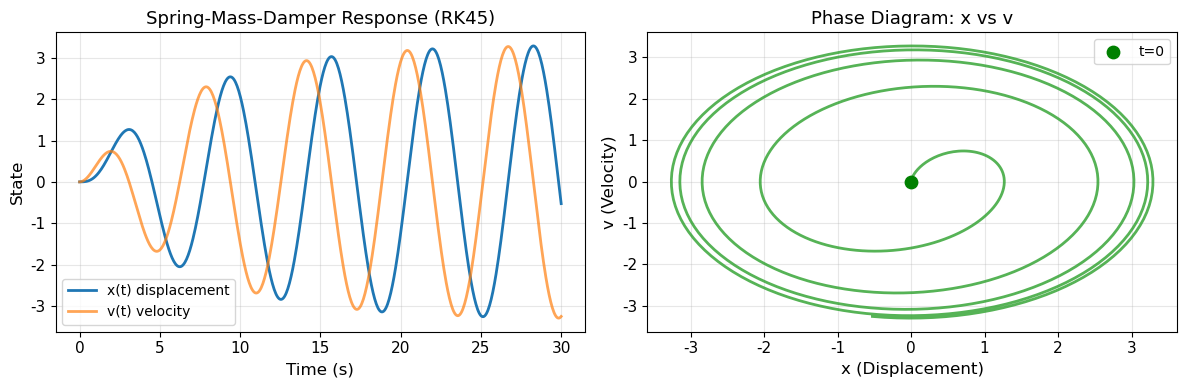

圖檔已儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_ODE\figs\spring_mass_damper.png


In [22]:
# ─────────────────────────────────────────────────
# Example 2.2 - 二階 ODE（彈簧-質量-阻尼）轉換求解
# ─────────────────────────────────────────────────

def spring_ode(t, y, m=1.0, c=0.3, k=1.0):
    """
    彈簧-質量-阻尼 二階 ODE 轉一階系統
    y[0] = x (位移)
    y[1] = dx/dt (速度)
    外力: F(t) = sin(t)
    """
    y1, y2 = y
    F = np.sin(t)                      # 週期性外力
    dy1dt = y2
    dy2dt = (F - c * y2 - k * y1) / m
    return [dy1dt, dy2dt]

# 初始條件
y0 = [0.0, 0.0]          # 初始位移=0, 初始速度=0
t_span = (0.0, 30.0)
t_eval = np.linspace(0, 30, 600)

sol2 = solve_ivp(spring_ode, t_span, y0, method='RK45', t_eval=t_eval,
                 rtol=1e-6, atol=1e-8)

print(f"求解狀態: {sol2.message}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sol2.t, sol2.y[0], label='x(t) displacement', color='tab:blue')
axes[0].plot(sol2.t, sol2.y[1], label='v(t) velocity', color='tab:orange', alpha=0.7)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('State')
axes[0].set_title('Spring-Mass-Damper Response (RK45)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(sol2.y[0], sol2.y[1], color='tab:green', alpha=0.8)
axes[1].scatter(y0[0], y0[1], s=80, color='green', zorder=5, label='t=0')
axes[1].set_xlabel('x (Displacement)')
axes[1].set_ylabel('v (Velocity)')
axes[1].set_title('Phase Diagram: x vs v')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / 'spring_mass_damper.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"圖檔已儲存：{FIG_DIR / 'spring_mass_damper.png'}")

<a id="3"></a>
## 3. SciPy IVP 求解工具 `solve_ivp()`

### 3.1 基本語法與求解方法

```python
sol = solve_ivp(fun, t_span, y0, method='RK45', t_eval=None,
                args=(), rtol=1e-3, atol=1e-6, jac=None)
```

| 參數 | 說明 |
|------|------|
| `fun` | ODE 右端函數 `f(t, y)` 或 `f(t, y, *args)` |
| `t_span` | `(t0, tf)` 積分區間 |
| `y0` | 初始條件向量 |
| `method` | 求解方法（見下表） |
| `t_eval` | 回傳解的時間點（不影響精度） |
| `args` | 傳入 `fun` 的額外參數（tuple） |
| `rtol/atol` | 相對/絕對容差 |
| `jac` | Jacobian 矩陣（Stiff 方法使用） |

**可用求解方法：**

| Method | 適用 | 說明 |
|--------|------|------|
| `RK45` | Non-stiff（預設） | Dormand-Prince 4(5) 階 |
| `RK23` | Non-stiff | Bogacki-Shampine 2(3) 階 |
| `DOP853` | Non-stiff | 高精度 8 階 |
| `Radau` | **Stiff** | 隱式 Radau IIA 5 階 |
| `BDF` | **Stiff** | 隱式後向差分公式 |
| `LSODA` | 自動切換 | 自動判斷 Stiff/Non-stiff |

Method         nfev     njev      步驟數          最終值
--------------------------------------------------
RK45            410        0      200    -0.049794
RK23           1178        0      200    -0.049793
DOP853          353        0      200    -0.049794
Radau           819        1      200    -0.049794
BDF             293        1      200    -0.049794
LSODA           181        0      200    -0.049794


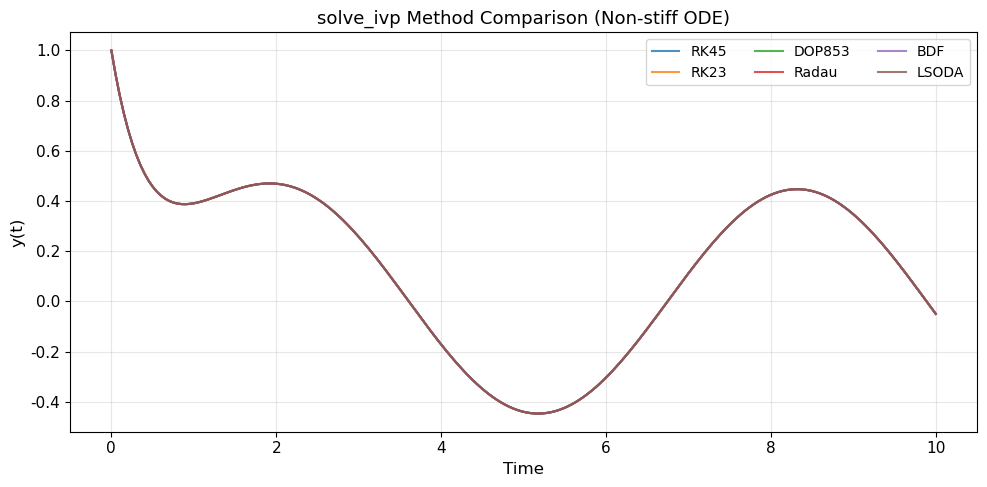

圖檔已儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_ODE\figs\method_comparison.png


In [23]:
# ─────────────────────────────────────────────────
# Example 3.1 - solve_ivp 六種方法比較（Non-stiff 問題）
# ─────────────────────────────────────────────────

def test_ode(t, y):
    """測試 ODE: y' = -2y + sin(t), 解析解已知"""
    return [-2.0 * y[0] + np.sin(t)]

y0 = [1.0]
t_span = (0.0, 10.0)
t_eval = np.linspace(0, 10, 200)

# 所有六種方法
methods = ['RK45', 'RK23', 'DOP853', 'Radau', 'BDF', 'LSODA']
results = {}

print(f"{'Method':<10} {'nfev':>8} {'njev':>8} {'步驟數':>8} {'最終值':>12}")
print("-" * 50)
for m in methods:
    sol = solve_ivp(test_ode, t_span, y0, method=m, t_eval=t_eval, rtol=1e-6, atol=1e-9)
    results[m] = sol
    njev = sol.njev if hasattr(sol, 'njev') and sol.njev is not None else 0
    print(f"{m:<10} {sol.nfev:>8} {njev:>8} {sol.t.shape[0]:>8} {sol.y[0,-1]:>12.6f}")

# 繪圖比較
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']
for (m, sol), c in zip(results.items(), colors):
    ax.plot(sol.t, sol.y[0], label=m, color=c, alpha=0.8, linewidth=1.5)

ax.set_xlabel('Time')
ax.set_ylabel('y(t)')
ax.set_title('solve_ivp Method Comparison (Non-stiff ODE)')
ax.legend(ncol=3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / 'method_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"圖檔已儲存：{FIG_DIR / 'method_comparison.png'}")

### 3.2 精度控制與外部輸入函數

**容差設定建議：**

| 用途 | `rtol` | `atol` |
|------|--------|--------|
| 快速試算 | `1e-3`（預設） | `1e-6`（預設） |
| 一般工程 | `1e-6` | `1e-8` |
| 高精度 | `1e-8` | `1e-10` |

**傳遞參數至 ODE 函數：** 使用 `args` 參數（tuple 型態）

```python
def ode(t, y, k, T_in):
    return [-k * y[0], k * y[0] - y[1] / T_in]

sol = solve_ivp(ode, t_span, y0, args=(k_val, Tin_val), ...)
```

**外部輸入函數（強迫函數）：** 使用 `np.interp()` 插值

```python
def ode_with_input(t, y, t_data, u_data):
    u = np.interp(t, t_data, u_data)   # 從數據插值取得當前輸入
    return [u - y[0]]
```

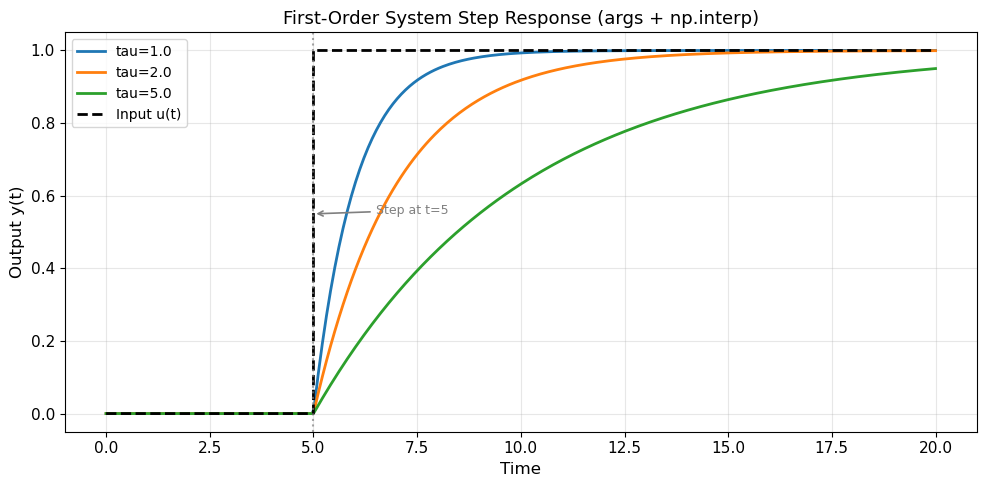

圖檔已儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_ODE\figs\step_response.png


In [34]:
# ─────────────────────────────────────────────────
# Example 3.2 - 步階輸入響應 + args 參數傳遞示範
# ─────────────────────────────────────────────────

def first_order_step(t, y, tau, t_data, u_data):
    """
    一階系統對步階輸入的響應
    tau * dy/dt = u(t) - y
    """
    u = np.interp(t, t_data, u_data)   # 插值取得當前輸入
    dydt = (u - y[0]) / tau
    return [dydt]

# 建立步階輸入訊號
t_input = np.array([0, 4.999, 5.0, 20.0])
u_input = np.array([0, 0.0,   1.0,  1.0])   # t=5 時步階從 0→1

# 不同時間常數的響應
tau_values = [1.0, 2.0, 5.0]
t_span_step = (0.0, 20.0)
t_eval_step = np.linspace(0, 20, 400)

fig, ax = plt.subplots(figsize=(10, 5))

for tau in tau_values:
    sol_step = solve_ivp(
        first_order_step, t_span_step, [0.0], method='RK45',
        t_eval=t_eval_step, args=(tau, t_input, u_input),
        rtol=1e-6, atol=1e-8
    )
    ax.plot(sol_step.t, sol_step.y[0], label=f'tau={tau}')

# 繪製輸入訊號與步階標記
ax.plot(t_input, u_input, 'k--', linewidth=2, label='Input u(t)')
ax.axvline(x=5.0, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.annotate('Step at t=5', xy=(5.0, 0.55), xytext=(6.5, 0.55),
            fontsize=9, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))
ax.set_xlabel('Time')
ax.set_ylabel('Output y(t)')
ax.set_title('First-Order System Step Response (args + np.interp)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / 'step_response.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"圖檔已儲存：{FIG_DIR / 'step_response.png'}")

### 3.3 CSTR 動態模擬：多穩態分析

CSTR 能量方程式具有「多穩態」（multiple steady states）特性：在特定參數下，相同操作條件可存在多個穩定操作點。本節使用 **da=0.5, phi=6, B=50, beta=0.5** 的三穩態參數集（由 Uppal-Ray-Poore 分析確認）。

**穩態結構分析（解穩態方程 $T_{ss} = B \cdot Da \cdot (1-x_{ss})/(Da+\beta)$）：**

| 穩態 | $x_{ss}$ | $T_{ss}$ | 穩定性 |
|------|----------|----------|--------|
| SS1（低溫） | ≈ 0.995 | ≈ 0.11 | 穩定 |
| SS2（中溫） | ≈ 0.973 | ≈ 0.68 | **不穩定（鞍點）** |
| SS3（高溫） | ≈ 0.649 | ≈ 8.78 | 穩定 |

本範例將模擬三種不同初始條件，觀察系統收斂至 SS1（低溫）或 SS3（高溫）。


IC1: x0=0.80, T0=0.0
  → 最終穩態: x=0.9954, T=0.1140
IC2: x0=0.95, T0=8.5
  → 最終穩態: x=0.6487, T=8.7824
IC3: x0=0.80, T0=4.0
  → 最終穩態: x=0.6487, T=8.7824


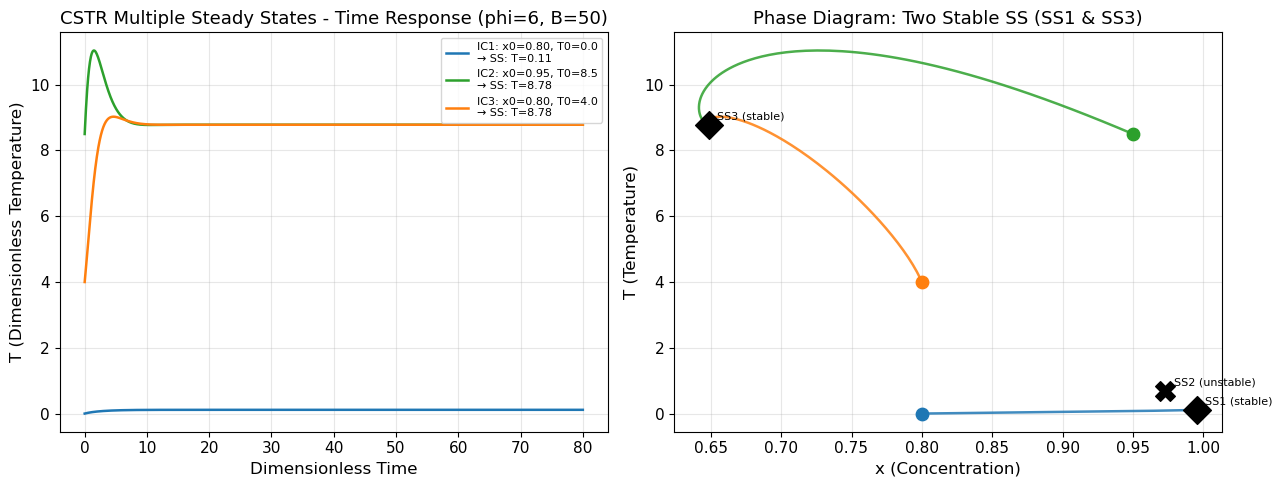

圖檔已儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_ODE\figs\cstr_multiple_ss.png


In [51]:
# ─────────────────────────────────────────────────
# Example 3.3 - CSTR 多穩態動態模擬
# 參數：phi=6, B=50, Da=0.5, beta=0.5
# 三個穩態：SS1(x≈0.9955,T≈0.11), SS2(unstable,x≈0.973,T≈0.68), SS3(x≈0.65,T≈8.75)
# ─────────────────────────────────────────────────

def cstr_ode_full(t, y, Da=0.5, phi=6.0, B=50.0, beta=0.5, yc=0.0):
    """
    CSTR ODE 三穩態版
    dxdt = -Da*x*exp(-phi/(1+T)) + Da*(1-x)
    dTdt =  B*Da*x*exp(-phi/(1+T)) - Da*T - beta*(T-yc)
          = B*reaction - Da*T - beta*(T-yc)   ← 注意: B*reaction, 非 Da*B*reaction
    """
    x, T = y
    exp_term = np.exp(-phi / (1.0 + T))
    reaction = Da * x * exp_term              # = Da * x * exp(-phi/(1+T))
    dxdt = -reaction + Da * (1.0 - x)
    dTdt = B * reaction - Da * T - beta * (T - yc)   # 熱產生 = B*reaction
    return [dxdt, dTdt]

# 三組初始條件：分別收斂至 SS1 和 SS3
initial_conditions = [
    ([0.8,  0.0], 'IC1: x0=0.80, T0=0.0'),
    ([0.95, 8.5], 'IC2: x0=0.95, T0=8.5'),
    ([0.80, 4.0], 'IC3: x0=0.80, T0=4.0'),
]

t_span_cstr = (0.0, 80.0)
t_eval_cstr = np.linspace(0, 80, 1600)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['tab:blue', 'tab:green', 'tab:orange']

for (y0_i, label), color in zip(initial_conditions, colors):
    sol_i = solve_ivp(cstr_ode_full, t_span_cstr, y0_i, method='Radau',
                      t_eval=t_eval_cstr, rtol=1e-8, atol=1e-10)
    x_ss = sol_i.y[0, -1]
    T_ss = sol_i.y[1, -1]
    axes[0].plot(sol_i.t, sol_i.y[1], label=f'{label}\n→ SS: T={T_ss:.2f}',
                 color=color, linewidth=1.8)
    axes[1].plot(sol_i.y[0], sol_i.y[1], color=color, alpha=0.85, linewidth=1.8)
    axes[1].scatter(y0_i[0], y0_i[1], s=80, color=color, marker='o', zorder=5)
    axes[1].scatter(x_ss, T_ss, s=120, color=color, marker='*', zorder=6)
    print(f"{label}")
    print(f"  → 最終穩態: x={x_ss:.4f}, T={T_ss:.4f}")

# 在相平面標記三個穩態位置（菱形符號）
ss_points = [
    (0.9955, 0.11,  'SS1 (stable)'),
    (0.9730, 0.68,  'SS2 (unstable)'),
    (0.6487, 8.78,  'SS3 (stable)'),
]
markers = ['D', 'X', 'D']
for (xs, Ts, lbl), mk in zip(ss_points, markers):
    axes[1].scatter(xs, Ts, s=200, marker=mk, color='black', zorder=7)
    axes[1].annotate(lbl, (xs, Ts), textcoords='offset points',
                     xytext=(6, 4), fontsize=8)

axes[0].set_xlabel('Dimensionless Time')
axes[0].set_ylabel('T (Dimensionless Temperature)')
axes[0].set_title('CSTR Multiple Steady States - Time Response (phi=6, B=50)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('x (Concentration)')
axes[1].set_ylabel('T (Temperature)')
axes[1].set_title('Phase Diagram: Two Stable SS (SS1 & SS3)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / 'cstr_multiple_ss.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"圖檔已儲存：{FIG_DIR / 'cstr_multiple_ss.png'}")

<a id="4"></a>
## 4. Stiff 常微分方程式

### 4.1 識別 Stiff 問題

**剛性比（Stiffness Ratio, SR）：** 

$$
SR = \frac{\max |\text{Re}(\lambda_i)|}{\min |\text{Re}(\lambda_i)|}
$$

其中 $\lambda_i$ 為 Jacobian 矩陣 $\partial \mathbf{f}/\partial \mathbf{y}$ 的特徵值。

- $SR > 1000$：需要 Stiff 求解器（Radau/BDF）
- $SR > 10^6$：強 Stiff，必須使用隱式方法

**化工常見 Stiff 問題：**

| 系統類型 | 原因 |
|----------|------|
| 快速化學反應網路（活性自由基） | 濃度相差多個數量級 |
| 燃燒反應動力學 | 快速/慢速反應共存 |
| 質傳-反應耦合（薄膜理論） | 空間尺度差異大 |
| 偏微分方程（方法of lines） | Δx 很小時 eigenvalue 很大 |

**數值 Jacobian 計算：**

$$
\left(\frac{\partial f_i}{\partial y_j}\right) \approx \frac{f_i(\ldots, y_j + h, \ldots) - f_i(\ldots, y_j, \ldots)}{h}, \quad h = \sqrt{\epsilon_{\text{machine}}}
$$

In [26]:
# ─────────────────────────────────────────────────
# Example 4.1 - 數值 Jacobian + 特徵值 + 剛性比計算
# ─────────────────────────────────────────────────

def numerical_jacobian(fun, t, y, h=None):
    """
    前向差分數值 Jacobian
    Returns: J[i,j] = ∂f_i/∂y_j
    """
    if h is None:
        h = np.sqrt(np.finfo(float).eps)
    n = len(y)
    f0 = np.array(fun(t, y))
    J = np.zeros((n, n))
    for j in range(n):
        y_pert = y.copy()
        y_pert[j] += h
        J[:, j] = (np.array(fun(t, y_pert)) - f0) / h
    return J

# 使用 Van der Pol Stiff ODE 作為示範：y'' - mu*(1-y^2)*y' + y = 0
# 轉換：y1=y, y2=y'
def vdp_ode(t, y, mu=100.0):
    """Van der Pol ODE (mu 大時為 Stiff 問題)"""
    return [y[1], mu * (1 - y[0]**2) * y[1] - y[0]]

# 計算不同 mu 值的剛性比
print("Van der Pol ODE 剛性比分析：")
print(f"{'mu':>8} {'max|Re(λ)|':>14} {'min|Re(λ)|':>14} {'SR':>12}")
print("-" * 52)

for mu in [1, 10, 100, 1000]:
    y_test = np.array([2.0, 0.0])   # 初始點
    J = numerical_jacobian(lambda t, y: vdp_ode(t, y, mu), 0, y_test)
    eigenvalues = np.linalg.eigvals(J)
    re_abs = np.abs(np.real(eigenvalues))
    re_abs_nonzero = re_abs[re_abs > 1e-12]
    if len(re_abs_nonzero) >= 2:
        SR = re_abs_nonzero.max() / re_abs_nonzero.min()
    else:
        SR = float('inf')
    print(f"{mu:>8} {re_abs.max():>14.2f} {re_abs.min():>14.4f} {SR:>12.1f}")

print("\n剛性比 > 1000 → 建議使用 Stiff 求解器（Radau/BDF）")

Van der Pol ODE 剛性比分析：
      mu     max|Re(λ)|     min|Re(λ)|           SR
----------------------------------------------------
       1           2.62         0.3820          6.9
      10          29.97         0.0334        898.0
     100         300.00         0.0033      89998.0
    1000        3000.00         0.0003    8999998.0

剛性比 > 1000 → 建議使用 Stiff 求解器（Radau/BDF）


### 4.2 Non-stiff 與 Stiff 求解器效能比較

當使用 Non-stiff 求解器（如 RK45）求解 Stiff ODE 時，為維持穩定性需要極小步長，導致 `nfev`（ODE 函數呼叫次數）暴增。

**診斷指標：**
- `sol.nfev`：ODE 函數呼叫次數（越少越好）
- `sol.njev`：Jacobian 計算次數（隱式方法使用）
- `sol.nlu`：LU 分解次數（隱式方法使用）

使用 Van der Pol ODE（$\mu=1000$）比較各求解器效能：

Van der Pol ODE (mu=1000.0): 求解器效能比較
Method         nfev status          time(s)
---------------------------------------------
RK45        8120324 OK              123.861
Radau          2609 OK                0.107
BDF            1589 OK                0.131
LSODA          1419 OK                0.018


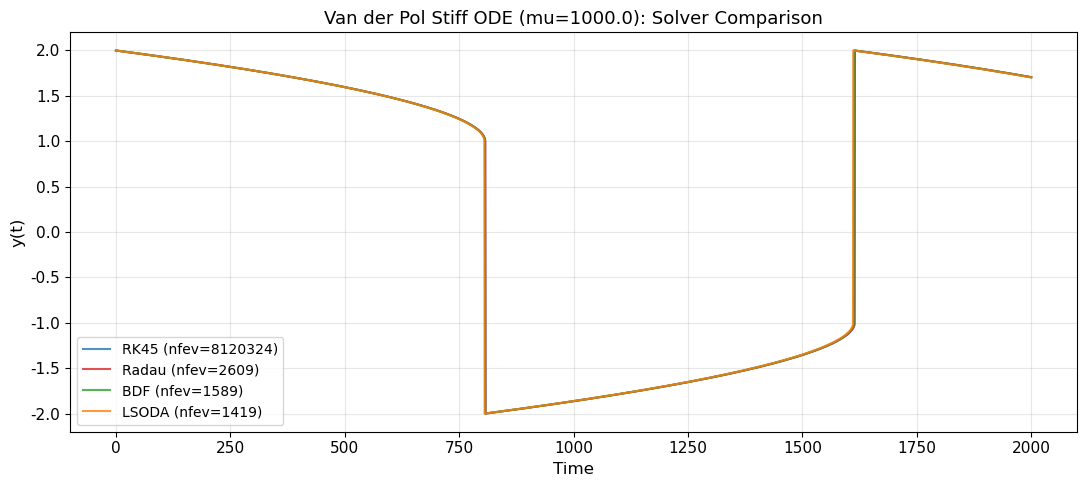

圖檔已儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_ODE\figs\stiff_comparison.png


In [27]:
# ─────────────────────────────────────────────────
# Example 4.2 - Stiff ODE：RK45 vs Radau vs BDF vs LSODA
# ─────────────────────────────────────────────────
import time

MU_STIFF = 1000.0   # 高 mu → 強 Stiff

def vdp_stiff(t, y):
    return vdp_ode(t, y, mu=MU_STIFF)

y0_vdp = [2.0, 0.0]
t_span_vdp = (0.0, 2 * MU_STIFF)   # 推薦積分終點 ≈ 0.7*mu 週期
t_eval_vdp = np.linspace(0, 2 * MU_STIFF, 3000)

methods_test = {
    'RK45':  {'max_step': np.inf},        # Non-stiff（可能很慢）
    'Radau': {},                            # Stiff
    'BDF':   {},                            # Stiff
    'LSODA': {},                            # 自動
}

print(f"Van der Pol ODE (mu={MU_STIFF}): 求解器效能比較")
print(f"{'Method':<10} {'nfev':>8} {'status':<12} {'time(s)':>10}")
print("-" * 45)

sols_stiff = {}
for m, kw in methods_test.items():
    t0 = time.perf_counter()
    try:
        sol_s = solve_ivp(vdp_stiff, t_span_vdp, y0_vdp, method=m,
                          t_eval=t_eval_vdp, rtol=1e-4, atol=1e-6,
                          max_step=kw.get('max_step', np.inf))
        elapsed = time.perf_counter() - t0
        sols_stiff[m] = sol_s
        print(f"{m:<10} {sol_s.nfev:>8} {'OK':<12} {elapsed:>10.3f}")
    except Exception as e:
        elapsed = time.perf_counter() - t0
        print(f"{m:<10} {'N/A':>8} {str(e)[:12]:<12} {elapsed:>10.3f}")

# 繪圖（僅顯示成功求解的方法）
fig, ax = plt.subplots(figsize=(11, 5))
color_map = {'RK45': 'tab:blue', 'Radau': 'tab:red',
             'BDF': 'tab:green', 'LSODA': 'tab:orange'}
for m, sol_s in sols_stiff.items():
    if sol_s.success:
        ax.plot(sol_s.t, sol_s.y[0], label=f'{m} (nfev={sol_s.nfev})',
                color=color_map.get(m), linewidth=1.5, alpha=0.8)

ax.set_xlabel('Time')
ax.set_ylabel('y(t)')
ax.set_title(f'Van der Pol Stiff ODE (mu={MU_STIFF}): Solver Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / 'stiff_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"圖檔已儲存：{FIG_DIR / 'stiff_comparison.png'}")

<a id="5"></a>
## 5. 微分代數方程式系統 (DAE)

### 5.1 DAE 問題形式與求解策略

**DAE 一般形式：**

$$
M\,\frac{d\mathbf{y}}{dt} = \mathbf{f}(t,\, \mathbf{y})
$$

其中 $M$ 為奇異質量矩陣（某些行全為零）。

**三組分可逆反應系統：** $A \rightleftharpoons B \rightleftharpoons C$

$$
\frac{dC_A}{dt} = -k_1 C_A + k_{-1} C_B
$$
$$
\frac{dC_B}{dt} = k_1 C_A - k_{-1} C_B - k_2 C_B + k_{-2} C_C
$$
$$
0 = C_A + C_B + C_C - C_{total} \quad \text{（守恆代數約束）}
$$

**SciPy 處理 DAE 的策略：**
1. **奇異擾動法**：代數方程替換為快速 ODE（$\epsilon \ll 1$）
2. **直接消去法**：利用代數約束消去一個變數，降階為純 ODE 系統

守恆誤差（最大值）: 1.11e-16  ✓ 滿足代數約束
最終穩態: C_A=0.1433, C_B=0.2860, C_C=0.5707
sum = 1.000000


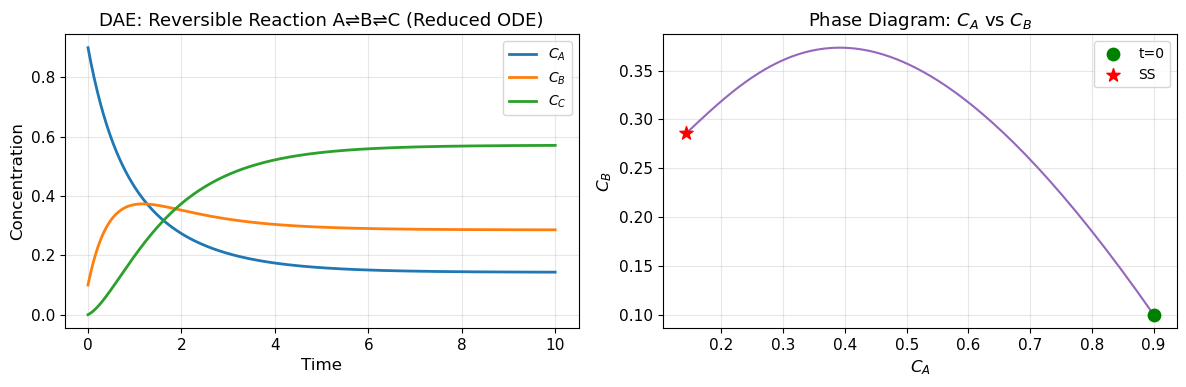

圖檔已儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_ODE\figs\dae_reaction.png


In [28]:
# ─────────────────────────────────────────────────
# Example 5.1 - DAE 三組分可逆反應（直接消去法：消去 C_C 降為純 ODE）
# ─────────────────────────────────────────────────

# 反應參數
k1, km1 = 1.0, 0.5    # A⇌B
k2, km2 = 0.8, 0.4    # B⇌C
C_total = 1.0          # 守恆量

# ─── 方法一：直接消去法（消去 C_C，降為 2D ODE）───
def dae_reduced(t, y):
    """
    利用 C_C = C_total - C_A - C_B 消去 C_C
    只求解 [C_A, C_B]
    """
    CA, CB = y
    CC = C_total - CA - CB
    dCA = -k1 * CA + km1 * CB
    dCB = k1 * CA - km1 * CB - k2 * CB + km2 * CC
    return [dCA, dCB]

y0_dae = [0.9, 0.1]    # 初始：C_A=0.9, C_B=0.1, C_C=0
t_span_dae = (0.0, 10.0)
t_eval_dae = np.linspace(0, 10, 300)

sol_dae = solve_ivp(dae_reduced, t_span_dae, y0_dae, method='Radau',
                    t_eval=t_eval_dae, rtol=1e-8, atol=1e-10)

CA = sol_dae.y[0]
CB = sol_dae.y[1]
CC = C_total - CA - CB

# 等比驗證守恆
conservation_error = np.max(np.abs(CA + CB + CC - C_total))
print(f"守恆誤差（最大值）: {conservation_error:.2e}  ✓ 滿足代數約束")
print(f"最終穩態: C_A={CA[-1]:.4f}, C_B={CB[-1]:.4f}, C_C={CC[-1]:.4f}")
print(f"sum = {CA[-1]+CB[-1]+CC[-1]:.6f}")

# 繪圖
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sol_dae.t, CA, label='$C_A$', color='tab:blue')
axes[0].plot(sol_dae.t, CB, label='$C_B$', color='tab:orange')
axes[0].plot(sol_dae.t, CC, label='$C_C$', color='tab:green')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Concentration')
axes[0].set_title('DAE: Reversible Reaction A⇌B⇌C (Reduced ODE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 三元相圖（濃度空間）
axes[1].plot(CA, CB, color='tab:purple', linewidth=1.5)
axes[1].scatter(CA[0], CB[0], s=80, color='green', zorder=5, label='t=0')
axes[1].scatter(CA[-1], CB[-1], s=100, color='red', marker='*', zorder=5, label='SS')
axes[1].set_xlabel('$C_A$')
axes[1].set_ylabel('$C_B$')
axes[1].set_title('Phase Diagram: $C_A$ vs $C_B$')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / 'dae_reaction.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"圖檔已儲存：{FIG_DIR / 'dae_reaction.png'}")

<a id="6"></a>
## 6. 邊界值問題 (BVP)

### 6.1 `solve_bvp()` 基本語法

BVP 形式：

$$
\frac{d\mathbf{y}}{dx} = \mathbf{f}(x,\, \mathbf{y}), \quad \mathbf{g}(\mathbf{y}(a),\, \mathbf{y}(b)) = \mathbf{0}
$$

```python
from scipy.integrate import solve_bvp

sol = solve_bvp(fun, bc, x, y, p=None, tol=1e-3, max_nodes=1000)
```

| 參數 | 說明 |
|------|------|
| `fun(x, y)` | ODE 右端函數，`y.shape=(n, N)`，向量化 |
| `bc(ya, yb)` | 邊界條件函數，回傳殘差向量 |
| `x` | 初始網格（不等間距亦可），1D array |
| `y` | 初始猜測，`shape=(n, len(x))` |
| `p` | 未知參數（參數估計 BVP 使用） |
| `tol` | 容差（預設 1e-3） |

**返回物件：**
- `sol.x`：最終網格節點
- `sol.y`：各節點解值 `shape=(n, N)`
- `sol.sol(x_eval)`：連續插值函數（callable）
- `sol.success`：是否收斂

### 6.2 化工 BVP 範例：管柱反應器（PFR）

**問題：** 考慮絕熱 PFR 中一級反應，沿軸向 $z \in [0, 1]$ 的濃度與溫度分佈。

$$
\frac{dC}{dz} = -Da \cdot C \cdot e^{-E_a/(1+T)}, \quad C(0) = 1
$$

$$
\frac{dT}{dz} = \beta \cdot Da \cdot C \cdot e^{-E_a/(1+T)}, \quad T(0) = 0
$$

本節使用 `solve_bvp` 以 IVP 等價形式求解 PFR，展示 BVP 介面的邊界條件設定、初始猜測與連續插值求解技巧。參數 $Da=5$，$E_a=2$，$\beta=0.3$ 使出口轉化率約 55%，圖形清晰可見軸向濃度遞減與溫度遞增的共軛關係，且兩者嚴格滿足能量守恆 $T(z) = \beta \cdot (1 - C(z))$。

BVP 求解狀態: The algorithm converged to the desired accuracy.
最終網格節點數: 30
出口濃度 C(1) = 0.4506  (轉化率 = 54.9%)
出口溫度 T(1) = 0.1648
能量守恆驗證 ΔT = β*(1-C) = 0.1648 vs T(1) = 0.1648


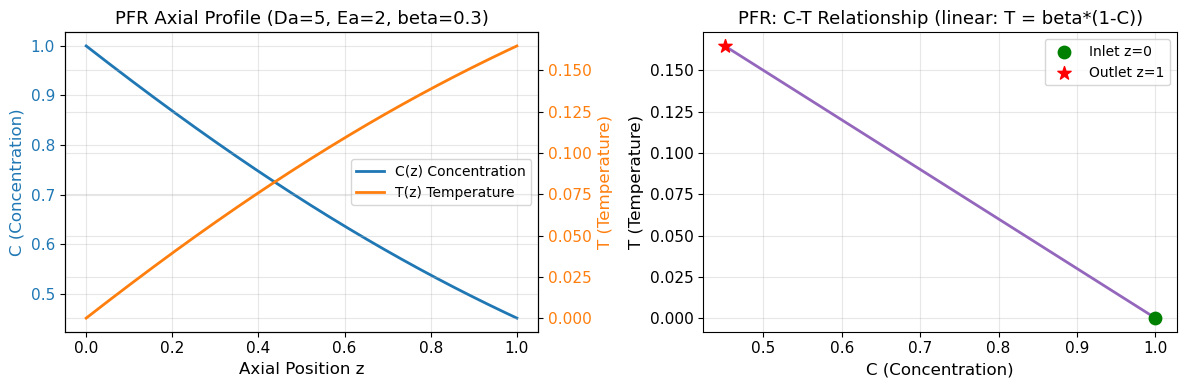

圖檔已儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_ODE\figs\pfr_bvp.png


In [35]:
# ─────────────────────────────────────────────────
# Example 6.1 - PFR 一階反應軸向濃度與溫度分佈（BVP 示範）
# 參數：Da=5.0, Ea=2.0, beta=0.3 → 出口轉化率約 50%
# ─────────────────────────────────────────────────

def pfr_ode(z, y, Da=5.0, Ea=2.0, beta=0.3):
    """
    PFR ODE（BVP 形式）
    y[0] = C (無因次濃度，入口 C=1)
    y[1] = T (無因次溫度偏差，入口 T=0)
    dC/dz = -Da * C * exp(-Ea/(1+T))
    dT/dz =  beta * Da * C * exp(-Ea/(1+T))   (能量守恆)
    """
    C, T = y
    reaction = Da * C * np.exp(-Ea / (1.0 + T))
    dCdz = -reaction
    dTdz = beta * reaction
    return np.vstack([dCdz, dTdz])

def pfr_bc(ya, yb):
    """邊界條件：入口 C(0)=1, T(0)=0（IVP 等價形式）"""
    return np.array([ya[0] - 1.0, ya[1] - 0.0])

# 初始網格與猜測
z_mesh = np.linspace(0, 1, 30)
y_guess = np.zeros((2, z_mesh.size))
y_guess[0] = 1.0 - 0.5 * z_mesh   # 線性猜測 C: 1→0.5
y_guess[1] = 0.3 * 0.5 * z_mesh   # 線性猜測 T: 0→0.15

sol_bvp = solve_bvp(pfr_ode, pfr_bc, z_mesh, y_guess, tol=1e-6, max_nodes=500)
print(f"BVP 求解狀態: {sol_bvp.message}")
print(f"最終網格節點數: {len(sol_bvp.x)}")

# 密集點評估
z_plot = np.linspace(0, 1, 300)
y_plot = sol_bvp.sol(z_plot)
C_plot = y_plot[0]
T_plot = y_plot[1]

print(f"出口濃度 C(1) = {C_plot[-1]:.4f}  (轉化率 = {(1-C_plot[-1])*100:.1f}%)")
print(f"出口溫度 T(1) = {T_plot[-1]:.4f}")
print(f"能量守恆驗證 ΔT = β*(1-C) = {0.3*(1-C_plot[-1]):.4f} vs T(1) = {T_plot[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左圖：雙 Y 軸（C 與 T 尺度不同，分開顯示）
ax0_left = axes[0]
ax0_right = ax0_left.twinx()
lc, = ax0_left.plot(z_plot, C_plot, label='C(z) Concentration', color='tab:blue', linewidth=2)
lt, = ax0_right.plot(z_plot, T_plot, label='T(z) Temperature', color='tab:orange', linewidth=2)
ax0_left.set_xlabel('Axial Position z')
ax0_left.set_ylabel('C (Concentration)', color='tab:blue')
ax0_right.set_ylabel('T (Temperature)', color='tab:orange')
ax0_left.tick_params(axis='y', labelcolor='tab:blue')
ax0_right.tick_params(axis='y', labelcolor='tab:orange')
ax0_left.set_title('PFR Axial Profile (Da=5, Ea=2, beta=0.3)')
ax0_left.legend(handles=[lc, lt], loc='center right')
ax0_left.grid(True, alpha=0.3)

axes[1].plot(C_plot, T_plot, color='tab:purple', linewidth=2)
axes[1].scatter(C_plot[0], T_plot[0], s=80, color='green', zorder=5, label='Inlet z=0')
axes[1].scatter(C_plot[-1], T_plot[-1], s=100, color='red', marker='*', zorder=5, label='Outlet z=1')
axes[1].set_xlabel('C (Concentration)')
axes[1].set_ylabel('T (Temperature)')
axes[1].set_title('PFR: C-T Relationship (linear: T = beta*(1-C))')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / 'pfr_bvp.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"圖檔已儲存：{FIG_DIR / 'pfr_bvp.png'}")

<a id="6-3"></a>
### 6.3 含未知參數的 BVP（特徵值問題）

當 BVP 中包含未知參數時，使用 `solve_bvp(..., p=p_guess)` 傳遞初始猜測。

**Mathieu 方程式（特徵值 BVP）**

$$
y'' + \lambda\, y = 0, \quad y(0) = 1,\; y\!\left(\frac{\pi}{2}\right) = 0
$$

要求 $\lambda > 0$（振盪解），最小特徵值 $\lambda = 1$（解析解）。

函數 `fun(x, y, p)` 接收當前參數 `p = [lambda]`，`bc(ya, yb, p)` 包含兩端邊界條件與參數約束。

> **應用：** 熱傳問題中的特徵值（分離變數法中的本徵值），反應擴散問題的 Thiele 模數估計等。

求解狀態: The algorithm converged to the desired accuracy.
估計特徵值 λ = 1.000000  (解析解 λ=1)


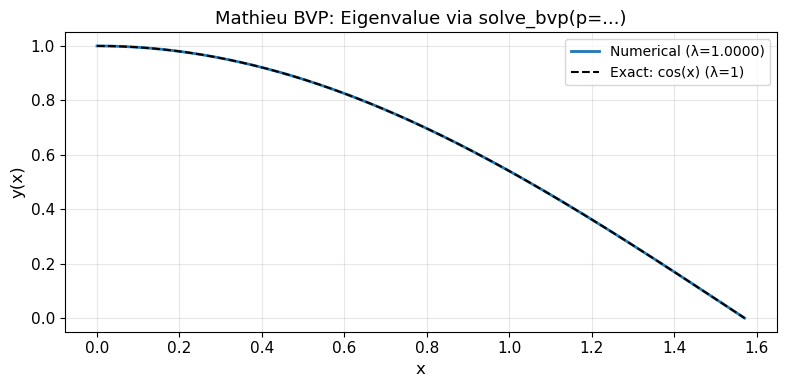

圖檔已儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_ODE\figs\mathieu_bvp.png


In [30]:
# ─────────────────────────────────────────────────
# Example 6.2 - Mathieu 方程式：特徵值（未知參數）BVP
# ─────────────────────────────────────────────────

def mathieu_fun(x, y, p):
    """
    y'' + λ*y = 0  轉一階
    y[0] = y, y[1] = y'
    p[0] = λ (待求特徵值)
    """
    lam = p[0]
    return np.vstack([y[1], -lam * y[0]])

def mathieu_bc(ya, yb, p):
    """
    邊界條件：y(0) = 1, y(π/2) = 0
    + 初始斜率約束 y'(0) = 0（諾伊曼條件）
    """
    return np.array([
        ya[0] - 1.0,           # y(0) = 1
        yb[0],                  # y(π/2) = 0
        ya[1],                  # y'(0) = 0
    ])

# 初始猜測
x_init = np.linspace(0, np.pi / 2, 30)
y_init = np.zeros((2, x_init.size))
y_init[0] = np.cos(x_init)    # 猜測 cos(x)
p_guess = [2.0]                # 猜測 λ≈2

sol_eigen = solve_bvp(mathieu_fun, mathieu_bc, x_init, y_init,
                      p=p_guess, tol=1e-8)
print(f"求解狀態: {sol_eigen.message}")
print(f"估計特徵值 λ = {sol_eigen.p[0]:.6f}  (解析解 λ=1)")

# 密集評估
x_eval = np.linspace(0, np.pi / 2, 200)
y_eval = sol_eigen.sol(x_eval)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_eval, y_eval[0], label=f'Numerical (λ={sol_eigen.p[0]:.4f})',
        color='tab:blue', linewidth=2)
ax.plot(x_eval, np.cos(x_eval), 'k--', label='Exact: cos(x) (λ=1)', linewidth=1.5)
ax.set_xlabel('x')
ax.set_ylabel('y(x)')
ax.set_title('Mathieu BVP: Eigenvalue via solve_bvp(p=...)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / 'mathieu_bvp.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"圖檔已儲存：{FIG_DIR / 'mathieu_bvp.png'}")

<a id="7"></a>
## 7. 課程總結

### 本單元學習成果

| 主題 | 關鍵技能 |
|------|----------|
| ODE 基礎 | 一階系統形式、高階 ODE 轉換方法 |
| `solve_ivp()` | 6 種方法選擇、rtol/atol 設定、args 參數 |
| Stiff ODE | 剛性比計算、Radau/BDF 使用時機 |
| DAE | 代數約束消去、守恆量驗證 |
| BVP | `solve_bvp()` 介面、初猜技巧、未知參數估計 |

### 求解器選擇總覽

```
問題類型
├── IVP（初值問題）
│   ├── Non-stiff → RK45 (預設) / DOP853（高精度）
│   └── Stiff (SR>1000) → Radau / BDF / LSODA（自動）
├── DAE（微分代數）
│   ├── 消去法（降階為純 ODE）→ 任意 IVP 求解器
│   └── 奇異擾動法 → Radau / BDF
└── BVP（邊界值）
    └── solve_bvp() → 搭配合理初猜，必要時加密網格
```

### 常見錯誤排查

| 症狀 | 可能原因 | 解決方案 |
|------|----------|----------|
| `sol.success = False` | 容差太嚴，`max_step` 太小 | 放寬容差，檢查 ODE 定義 |
| RK45 極慢 | 問題為 Stiff | 改用 Radau 或 BDF |
| `solve_bvp` 不收斂 | 初始猜測差 | 改善猜測，增加初始節點數 |
| 結果振盪雜亂 | `t_eval` 間距太疏 | 增加 `t_eval` 密度 |

---
*本課程演練端到端完整展示了 Python SciPy 處理 ODE/DAE/BVP 的核心工作流程，對應 MATLAB ode45/ode15s/bvp4c 指令的 Python 實作。*